In [23]:
from rheogp import SPGP
from rheogp.utils import compare_models
import pandas as pd
import numpy as np
from pathlib import Path
import time

file_path = Path.cwd().parent  / "demos" / "data" / "cnf_chirp.xlsx"
df = pd.read_excel(file_path)

omega_min = 0.003
omega_max = 3000

t = df.iloc[:, 0].values.astype(np.float32)  
strain = df.iloc[:, 1].values.astype(np.float32)
stress = df.iloc[:, 2].values.astype(np.float32) 

model = SPGP(model="springpot", kernel="linear",
             inducing_points=600, learning_rate=0.005, learning_rate_physics=0.005,
             omega_min=0.6, omega_max=3)
t0 = time.perf_counter()

model.fit(t, strain, stress)
elapsed = time.perf_counter() - t0
print(f"Training time: {elapsed:.1f} s  ({elapsed/60:.2f} min)")

print(model.summary())           # BIC, RMSE, R², all params with CI

  [springpot] step     0 | -ELBO 1.8033 | alpha=0.499 | wait 0
  [springpot] step   200 | -ELBO 0.7356 | alpha=0.239 | wait 0
  [springpot] step   400 | -ELBO 0.4781 | alpha=0.127 | wait 0
  [springpot] step   600 | -ELBO 0.4331 | alpha=0.088 | wait 11
  [springpot] step   800 | -ELBO 0.4282 | alpha=0.074 | wait 25
  [springpot] step  1000 | -ELBO 0.4271 | alpha=0.068 | wait 40
  [springpot] step  1200 | -ELBO 0.4266 | alpha=0.066 | wait 92
  [springpot] step  1400 | -ELBO 0.4267 | alpha=0.065 | wait 61
  [springpot] step  1600 | -ELBO 0.4265 | alpha=0.064 | wait 261
  [springpot] step  1800 | -ELBO 0.4264 | alpha=0.064 | wait 461
  [springpot] early stopping at step 1839

  [springpot] RMSE=0.7447  R²=0.8638  AIC=1203.6  BIC=1235.1  (k=6: shape 1 + prefactors 1 + GP 4)
  params: {'alpha': 0.06395099312067032}
  V: 192.347  95%CI [183.834, 199.36]
Training time: 27.3 s  (0.46 min)
  RheoGP  —  springpot
  Control        : strain-controlled (relaxation representation)
  Convolution    :

In [24]:
import torch

# ── physics parameters (α, β, τ_c) ──────────────────────────
print(model.gp_model_.phys.named_phys_params())
# {'alpha': 0.712, 'beta': 0.301, 'tau_c': 1.504}

# ── GP covariance hyperparameters ────────────────────────────
gp = model.gp_model_

# output scale  (s_f²  in  k = s_f² · κ)
outputscale = gp.covar_module.outputscale.item()
print(f"outputscale:  {outputscale:.6f}")

# lengthscale(s) — shape depends on kernel + ARD
# for RBF/Matern with ARD: one per feature dimension
lengthscale = gp.covar_module.base_kernel.lengthscale.detach()
print(f"lengthscale:  {lengthscale}")          # tensor([[ℓ₁, ℓ₂, ...]])
print(f"lengthscale:  {lengthscale.cpu().numpy()}")  # as numpy

# for LinearKernel (Phase 2 of rbf+linear): variance instead of lengthscale
if hasattr(gp.covar_module.base_kernel, 'variance'):
    variance = gp.covar_module.base_kernel.variance.item()
    print(f"linear variance: {variance:.6f}")

# ── likelihood noise ─────────────────────────────────────────
noise = model.likelihood_.noise.item()
print(f"noise variance: {noise:.6f}")

# ── constant mean ─────────────────────────────────────────────
mean_const = gp.mean_module.constant.item()
print(f"mean constant:  {mean_const:.6f}")

# ── everything at once ────────────────────────────────────────
print("\nAll named parameters:")
for name, param in gp.named_parameters():
    print(f"  {name:<45} {param.detach().cpu().numpy()}")

{'alpha': 0.06395099312067032}
outputscale:  0.632128


AttributeError: 'NoneType' object has no attribute 'detach'

In [ ]:
# check the range of your standardised feature
x_scaled = model.gp_model_.compute_x().detach().cpu().numpy()
print(f"x_scaled range: [{x_scaled.min():.3f}, {x_scaled.max():.3f}]")
print(f"x_scaled std:   {x_scaled.std():.3f}")   # should be ≈ 1 by construction

In [ ]:
def get_hyperparameters_physical(model):
    gp   = model.gp_model_
    lik  = model.likelihood_
    phys = gp.phys

    # scalers
    sy   = float(model.scaler_y_.scale_[0])   # σ_y  [Pa]
    my   = float(model.scaler_y_.mean_[0])    # μ_y  [Pa]

    # feature stds — one per input dimension
    # set by compute_x() during the last forward pass
    sx   = phys._feature_stds                 # list of σ_x per column

    out = {}

    # ── physics parameters (already in physical units) ───────
    out["physics"] = phys.named_phys_params()

    # ── noise: σ_n² · σ_y²  →  σ_n [Pa] ────────────────────
    noise_scaled   = lik.noise.item()
    out["noise_std_Pa"]      = (noise_scaled ** 0.5) * sy

    # ── mean constant: c·σ_y + μ_y  [Pa] ────────────────────
    c = gp.mean_module.constant.item()
    out["mean_constant_Pa"]  = c * sy + my

    # ── outputscale: s_f²·σ_y²  →  s_f [Pa] ────────────────
    os_scaled = gp.covar_module.outputscale.item()
    out["outputscale_Pa"]    = (os_scaled ** 0.5) * sy

    base = gp.covar_module.base_kernel

    # ── RBF / Matern lengthscales: ℓ · σ_x  [feature units] ─
    if hasattr(base, "lengthscale"):
        ls = base.lengthscale.detach().cpu().numpy().flatten()
        out["lengthscales_physical"] = {
            f"ell_{i}": float(ls[i]) * sx[i]
            for i in range(len(ls))
        }

    # ── LinearKernel variance: w²·σ_y/σ_x  [Pa/feature_unit] 
    if hasattr(base, "variance"):
        w2 = base.variance.item()
        out["linear_variances_physical"] = {
            f"w_{i}": (w2 ** 0.5) * sy / sx[i]
            for i in range(len(sx))
        }

    return out


params = get_hyperparameters_physical(model)
for k, v in params.items():
    print(f"{k}: {v}")

In [ ]:
import torch, gpytorch

gp, lik = model.gp_model_, model.likelihood_
phys = gp.phys

dev = phys.raw_alpha.device      # whatever device the model is on (cuda:0)

y = torch.as_tensor(
        model.scaler_y_.transform(stress.reshape(-1, 1)).ravel(),
        dtype=torch.float32, device=dev)          # <-- key change

mll = gpytorch.mlls.VariationalELBO(lik, gp, num_data=y.numel())

gp.eval(); lik.eval()
phys._gamma_scale_frozen = phys._feature_stds_frozen = True
raw = phys.raw_alpha
raw.requires_grad_(True)

with gpytorch.settings.cholesky_jitter(1e-6):
    x     = gp.compute_x()
    loss  = -mll(gp(x), y) * y.numel()
    grad, = torch.autograd.grad(loss, raw, create_graph=True)
    hess, = torch.autograd.grad(grad, raw)

phys._gamma_scale_frozen = phys._feature_stds_frozen = False

sd_raw   = float(hess.abs().rsqrt())
alpha    = phys.alpha.item()
sd_alpha = alpha * (1 - alpha) * sd_raw
print(f"alpha = {alpha:.4f} ± {sd_alpha:.4f}")

In [ ]:
def _resolve_gamma_scales(phys, n_features):
    gs = getattr(phys, "_gamma_scale", None)
    if gs is None:
        return [1.0] * n_features
    if hasattr(gs, "dim") and gs.dim() == 0:
        return [float(gs.item())] * n_features
    if hasattr(gs, "cpu"):
        gs = gs.detach().cpu().numpy().flatten().tolist()
        return (gs * n_features)[:n_features] if len(gs) == 1 else gs
    if isinstance(gs, (float, int)):
        return [float(gs)] * n_features
    return [float(g) for g in gs]


def get_hyperparameters_physical(model):
    gp   = model.gp_model_
    lik  = model.likelihood_
    phys = gp.phys

    sy = float(model.scaler_y_.scale_[0])
    my = float(model.scaler_y_.mean_[0])
    sx = phys._feature_stds

    # make sure _feature_stds and _gamma_scale are populated
    import torch, gpytorch
    gp.eval(); lik.eval()
    with torch.no_grad(), gpytorch.settings.cholesky_jitter(1e-6):
        _ = gp.compute_x()

    gamma_scales = _resolve_gamma_scales(phys, len(sx))

    out = {}
    out["physics"]          = phys.named_phys_params()
    out["noise_std_Pa"]     = (lik.noise.item() ** 0.5) * sy
    out["mean_constant_Pa"] = gp.mean_module.constant.item() * sy + my
    out["outputscale_Pa"]   = (gp.covar_module.outputscale.item() ** 0.5) * sy
    out["gamma_scales"]     = {f"gs_{i}": gamma_scales[i] for i in range(len(sx))}

    base = gp.covar_module.base_kernel

    if hasattr(base, "lengthscale"):
        ls = base.lengthscale.detach().cpu().numpy().flatten()
        out["lengthscales_physical"] = {
            f"ell_{i}": float(ls[i]) * sx[i] * gamma_scales[i]
            for i in range(len(ls))
        }

    if hasattr(base, "variance"):
        w2 = base.variance.item()
        out["linear_variances_physical"] = {
            f"w_{i}": (w2 ** 0.5) * sy / (sx[i] * gamma_scales[i])
            for i in range(len(sx))
        }

    return out


params = get_hyperparameters_physical(model)
for k, v in params.items():
    print(f"{k}: {v}")

In [ ]:
sigma_pred = model.predict(strain)
sigma_pred, sigma_std = model.predict(strain, return_std=True)

df = pd.DataFrame({
    "time": t.flatten(),
    "strain": strain.flatten(),   # use flatten if strain is 2D
    "sigma_pred": sigma_pred,
    "sigma_std": sigma_std
})

df.to_excel("predictions.xlsx", index=False)

model.plot_fit()
model.plot_prefactors()          # V(t) and G(t) with 95% CI
model.plot_Gstar(add_fft=True)               # G′, G″, phase angle
model.plot_convergence()

# compare all three models in one call
#best = compare_models({"SP": sp, "FKV": fkv, "FMM": fmm})

In [ ]:
sigma_pred = model.predict(strain)

In [ ]:
# --- Add GP input features: standardized (what GP sees) and raw (physical convolution) ---
import matplotlib.pyplot as plt

def _compute_raw_features(model):
    """
    Raw (unstandardized) convolution features x(t) for common models:
    Springpot, Fractional Maxwell (full, covers FMG/FML via params), Fractional Kelvin–Voigt (full).
    Also supports FKVS/FKVD second branch (γ or γ̇) when those kernels are used.
    Returns: t (N,), X_raw (N, d), labels (list[str])
    """
    import numpy as np
    import torch
    import rheogp.kernels as rk

    phys = model.gp_model_.phys
    t = model.t_.astype(np.float64)
    dt = float(np.median(np.diff(t)))
    gamma = torch.tensor(model.strain_, dtype=torch.float64)

    # Common helpers
    s = rk._lag_vector(gamma.shape[0], dt, device=gamma.device, dtype=gamma.dtype)
    gd = rk._gamma_dot(gamma, dt)  # γ̇(t)

    X_cols, labels = [], []

    # Springpot
    if isinstance(phys, rk.SpringpotKernel):
        alpha = torch.tensor(phys.alpha.item(), dtype=gamma.dtype)
        K = rk._caputo_kernel(s, alpha)
        x = rk._fft_convolve(gd, K, dt)
        X_cols.append(x.detach().cpu().numpy()); labels.append(r"D$^{\alpha}[\gamma]$ (s$^{-\alpha}$)")

    # Fractional Maxwell (full; FMG/FML via parameters)
    elif isinstance(phys, rk.FractionalMaxwellKernel):
        alpha = torch.tensor(phys.alpha.item(), dtype=gamma.dtype)
        beta  = torch.tensor(phys.beta.item(),  dtype=gamma.dtype)
        tau_c = torch.tensor(phys.tau_c.item(), dtype=gamma.dtype)
        K = rk._fmm_kernel(s, alpha, beta, tau_c)
        x = rk._fft_convolve(gd, K, dt)
        X_cols.append(x.detach().cpu().numpy()); labels.append(r"K$_{\mathrm{FMM}} \star \dot{\gamma}$ (–)")

    # Fractional Kelvin–Voigt (full)
    elif isinstance(phys, rk.FractionalKelvinVoigtKernel):
        alpha = torch.tensor(phys.alpha.item(), dtype=gamma.dtype)
        beta  = torch.tensor(phys.beta.item(),  dtype=gamma.dtype)
        Ka = rk._caputo_kernel(s, alpha)
        Kb = rk._caputo_kernel(s, beta)
        xa = rk._fft_convolve(gd, Ka, dt)
        xb = rk._fft_convolve(gd, Kb, dt)
        X_cols.append(xa.detach().cpu().numpy()); labels.append(r"D$^{\alpha}[\gamma]$ (s$^{-\alpha}$)")
        X_cols.append(xb.detach().cpu().numpy()); labels.append(r"D$^{\beta}[\gamma]$ (s$^{-\beta}$)")

    # Fractional Kelvin–Voigt S (springpot ∥ spring): [D^αγ, γ]
    elif isinstance(phys, rk.FKVSKernel):
        alpha = torch.tensor(phys.alpha.item(), dtype=gamma.dtype)
        Ka = rk._caputo_kernel(s, alpha)
        xa = rk._fft_convolve(gd, Ka, dt)           # D^α[γ]
        x0 = gamma                                  # γ
        X_cols.append(xa.detach().cpu().numpy()); labels.append(r"D$^{\alpha}[\gamma]$ (s$^{-\alpha}$)")
        X_cols.append(x0.detach().cpu().numpy());  labels.append(r"$\gamma$ (–)")

    # Fractional Kelvin–Voigt D (dashpot ∥ springpot): [D^βγ, γ̇]
    elif isinstance(phys, rk.FKVDKernel):
        beta = torch.tensor(phys.beta.item(), dtype=gamma.dtype)
        Kb = rk._caputo_kernel(s, beta)
        xb = rk._fft_convolve(gd, Kb, dt)           # D^β[γ]
        x1 = gd                                     # γ̇
        X_cols.append(xb.detach().cpu().numpy()); labels.append(r"D$^{\beta}[\gamma]$ (s$^{-\beta}$)")
        X_cols.append(x1.detach().cpu().numpy()); labels.append(r"$\dot{\gamma}$ (s$^{-1}$)")

    # Maxwell (classical): [exp kernel ★ γ̇]
    elif isinstance(phys, rk.MaxwellKernel):
        tau_c = torch.tensor(phys.tau_c.item(), dtype=gamma.dtype)
        Km = rk._maxwell_kernel(s, tau_c)
        x = rk._fft_convolve(gd, Km, dt)
        X_cols.append(x.detach().cpu().numpy()); labels.append(r"exp kernel $\star \dot{\gamma}$ (–)")

    else:
        # Fallback: use whatever compute_x() returned (but that is standardized)
        raise NotImplementedError(f"Raw features not implemented for {type(phys).__name__}")

    X_raw = np.vstack(X_cols).T  # (N, d)
    return t, X_raw, labels

# Standardized GP inputs (unitless)
X_norm = model.gp_model_.compute_x().detach().cpu().numpy()  # (N, d)

# Raw features (with physical units; see labels)
try:
    X_time, X_raw, X_labels = _compute_raw_features(model)
except Exception as e:
    print(f"Warning: could not compute raw features: {e}")
    X_time, X_raw, X_labels = model.t_, None, []

# Optional: quick figure overlaying strain on each raw feature
try:
    if X_raw is not None and X_raw.size:
        rows = X_raw.shape[1]
        fig_feat, ax = plt.subplots(rows, 1, figsize=(7, 2.6 * rows), sharex=True)
        if rows == 1: ax = [ax]
        for j in range(rows):
            ax[j].plot(X_time, X_raw[:, j], lw=1.5, label=X_labels[j] if j < len(X_labels) else f"x{j}")
            ax[j].set_ylabel(X_labels[j] if j < len(X_labels) else f"x{j}")
            ax2 = ax[j].twinx()
            ax2.plot(model.t_, model.strain_, 'k--', lw=1.1, alpha=0.8, label="γ(t)")
            ax2.set_ylabel("γ (–)")
            # Combined legend
            l1, lab1 = ax[j].get_legend_handles_labels()
            l2, lab2 = ax2.get_legend_handles_labels()
            ax[j].legend(l1 + l2, lab1 + lab2, loc="best")
            ax[j].grid(alpha=0.2)
        ax[-1].set_xlabel("t (s)")
        fig_feat.tight_layout()
        fig_feat.savefig("features_raw.pdf", bbox_inches="tight")
        fig_feat.savefig("features_raw.png", dpi=300, bbox_inches="tight")
        plt.close(fig_feat)
except Exception as e:
    print(f"Warning: feature plot failed: {e}")

# ---------- Save results (arrays + metadata) and figures ----------
from pathlib import Path
import numpy as np
import json
import matplotlib.pyplot as plt

# 6) Save arrays (compressed NPZ)
omega_curve = np.logspace(np.log10(model.omega_min),
                          np.log10(model.omega_max), model.n_omega)
scalar_pf   = {k: v["scalar_mean"] for k, v in model.prefactors_.items()}
Gp_curve, Gdp_curve = model.gp_model_.phys.Gstar(omega_curve, scalar_pf)

# 2) FFT dots (no plotting)
omega_fft, Gp_fft, Gdp_fft = model._chirp_fft_Gstar(eps=1e-12)
mask = (omega_fft >= model.omega_min) & (omega_fft <= model.omega_max)
omega_fft, Gp_fft, Gdp_fft = omega_fft[mask], Gp_fft[mask], Gdp_fft[mask]

# 3) Prefactors summary + (optional) samples
pref_summary = {
    name: {
        "mean":    info["mean"].tolist(),
        "lower":   info["lower"].tolist(),
        "upper":   info["upper"].tolist(),
        "scalar_mean":  info["scalar_mean"],
        "scalar_lower": info["scalar_lower"],
        "scalar_upper": info["scalar_upper"],
    }
    for name, info in model.prefactors_.items()
}

# Optional: include posterior samples (can be large)
include_samples = True
if include_samples:
    for name, info in model.prefactors_.items():
        pref_summary[name]["samples"] = info["samples"]  # keep as ndarray for .npz

# 4) Serializable metadata
meta = {
    "model_name": model.model_name,
    "kernel_name": model.kernel_name,
    "omega_min": model.omega_min,
    "omega_max": model.omega_max,
    "n_omega": model.n_omega,
    "phys_params": model.gp_model_.phys.named_phys_params(),
    "metrics": model.metrics_,
}

# 5) Training history (loss and tracked physics params)
history = {
    "loss": model.history_.get("loss", []),
    "params": model.history_.get("params", {}),
}

# 5) Save arrays in a compressed NPZ; save metadata (and prefactors summary) as JSON
out_dir = Path("outputs_cnf")
out_dir.mkdir(parents=True, exist_ok=True)

arrays = dict(
    time=model.t_,
    strain=model.strain_,
    stress=model.stress_,
    pred=sigma_pred,
    pred_std=sigma_std,
    omega_curve=omega_curve,
    Gp_curve=Gp_curve,
    Gdp_curve=Gdp_curve,
    omega_fft=omega_fft,
    Gp_fft=Gp_fft,
    Gdp_fft=Gdp_fft,
    # Added: features
    X_time=X_time if X_raw is not None else model.t_,
    X_norm=X_norm,                          # standardized GP inputs (unitless)
    X_raw=X_raw if X_raw is not None else np.array([]),  # raw features (physical units)
)

# Optional: add prefactor samples (already in your code when include_samples=True)
if include_samples:
    for name, info in model.prefactors_.items():
        arrays[f"pref_{name}_samples"] = info["samples"]
        
np.savez_compressed(out_dir / "rheogp_arrays.npz", **arrays)

# 7) Save metadata (JSON)
meta = {
    "model_name": model.model_name,
    "kernel_name": model.kernel_name,
    "inducing_points": model.inducing_points,
    "learning_rate": model.learning_rate,
    "omega_min": model.omega_min,
    "omega_max": model.omega_max,
    "n_omega": model.n_omega,
    "phys_params": {k: float(v) for k, v in model.gp_model_.phys.named_phys_params().items()},  # Ensure floats
    "metrics": {k: float(v) for k, v in model.metrics_.items() if not isinstance(v, dict)},  # Ensure floats
    "prefactors": {
        name: {
            "mean": info["mean"] if isinstance(info["mean"], list) else info["mean"].tolist(),
            "lower": info["lower"] if isinstance(info["lower"], list) else info["lower"].tolist(),
            "upper": info["upper"] if isinstance(info["upper"], list) else info["upper"].tolist(),
            "scalar_mean": float(info["scalar_mean"]),
            "scalar_lower": float(info["scalar_lower"]),
            "scalar_upper": float(info["scalar_upper"]),
        }
        for name, info in pref_summary.items()
    },
    "history": {
        "loss": list(history["loss"]),
        "tracked_params": {
            k: list(v) for k, v in history["params"].items()  # Ensure lists
        },
    },
    "X_labels": list(X_labels) if isinstance(X_labels, np.ndarray) else X_labels,  # Convert ndarray to list
}


with open(out_dir / "rheogp_meta.json", "w") as f:
    json.dump(meta, f, indent=2)



In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt

# Load
arrs = np.load("outputs_cnf/rheogp_arrays.npz", allow_pickle=True)
with open("outputs_cnf/rheogp_meta.json") as f:
    meta = json.load(f)

# Time-domain fit
t = arrs["time"]; stress = arrs["stress"]; pred = arrs["pred"]; pred_std = arrs["pred_std"]
plt.figure()
plt.plot(t, stress, 'k-', lw=1, label='Data')
plt.plot(t, pred, 'C0-', lw=1.5, label='GP mean')
plt.fill_between(t, pred - 2*pred_std, pred + 2*pred_std, color='C0', alpha=0.2, label='±2σ')
plt.xlabel('t (s)'); plt.ylabel('σ (Pa)')
plt.legend(); plt.tight_layout(); plt.show()

# Frequency-domain: G′/G″ with FFT dots
omega = arrs["omega_curve"]; Gp = arrs["Gp_curve"]; Gdp = arrs["Gdp_curve"]
omega_f = arrs["omega_fft"]; Gp_f = arrs["Gp_fft"]; Gdp_f = arrs["Gdp_fft"]

fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
for a in ax: a.set_xscale('log')
ax[0].plot(omega, Gp, 'C0-', label="G′(model)")
ax[0].scatter(omega_f, Gp_f, s=12, facecolors='none', edgecolors='C0', label='G′(FFT)')
ax[0].set_ylabel("G′ (Pa)"); ax[0].set_xlabel('ω (rad s$^{-1}$)'); ax[0].legend()

ax[1].plot(omega, Gdp, 'C1-', label="G″(model)")
ax[1].scatter(omega_f, Gdp_f, s=12, facecolors='none', edgecolors='C1', label='G″(FFT)')
ax[1].set_ylabel("G″ (Pa)"); ax[1].set_xlabel('ω (rad s$^{-1}$)'); ax[1].legend()

fig.suptitle(f"{meta['model_name']}  params: {meta['phys_params']}")
plt.tight_layout(); plt.show()

# Prefactor summaries
for name, info in meta["prefactors"].items():
    print(f"{name}: scalar_mean={info['scalar_mean']:.4g} "
          f"[{info['scalar_lower']:.4g}, {info['scalar_upper']:.4g}]")


  [springpot] step     0 | -ELBO 1.8033 | alpha=0.499 | wait 0
  [springpot] step   200 | -ELBO 0.7389 | alpha=0.238 | wait 0
  [springpot] step   400 | -ELBO 0.4823 | alpha=0.127 | wait 0
  [springpot] step   600 | -ELBO 0.4345 | alpha=0.087 | wait 0
  [springpot] step   800 | -ELBO 0.4298 | alpha=0.073 | wait 4
  [springpot] step  1000 | -ELBO 0.4288 | alpha=0.067 | wait 11
  [springpot] step  1200 | -ELBO 0.4286 | alpha=0.065 | wait 26
  [springpot] step  1400 | -ELBO 0.4286 | alpha=0.063 | wait 226
  [springpot] step  1600 | -ELBO 0.4286 | alpha=0.063 | wait 182
  [springpot] step  1800 | -ELBO 0.4286 | alpha=0.063 | wait 382
  [springpot] early stopping at step 1918

  [springpot] RMSE=0.7463  R²=0.8632  AIC=1209.4  BIC=1240.8  (k=6: shape 1 + prefactors 1 + GP 4)
  params: {'alpha': 0.06253574043512344}
  V: 192.151  95%CI [190.541, 193.478]
Training time: 14.6 s
  RheoGP  —  springpot
  Control        : strain-controlled (relaxation representation)
  Convolution    : steady  (fr

/scratch/phys/csm/mirandi1/rheogp_v0.3.0_dev_full/rheogp/rheogp/model.py:254: UserWarning: Predicting with steady (periodic) features: the new input is assumed periodic. For step/one-shot protocols pass convolution='causal'.
  warnings.warn(


PosixPath('cnf_scottblair_fit')

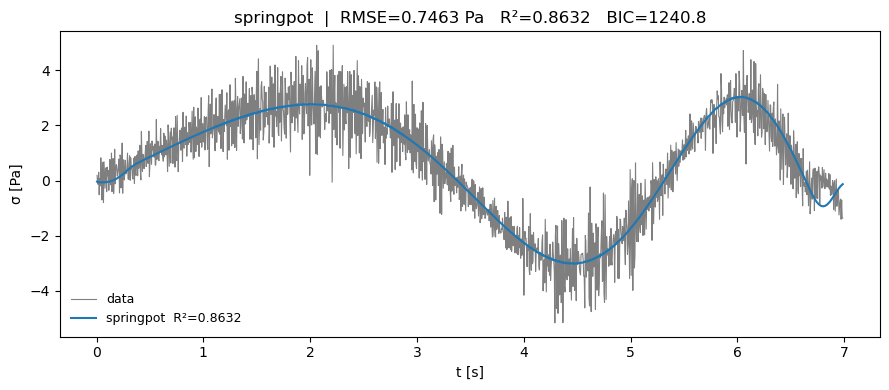

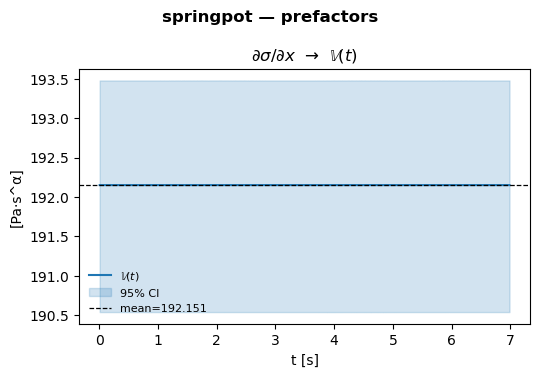

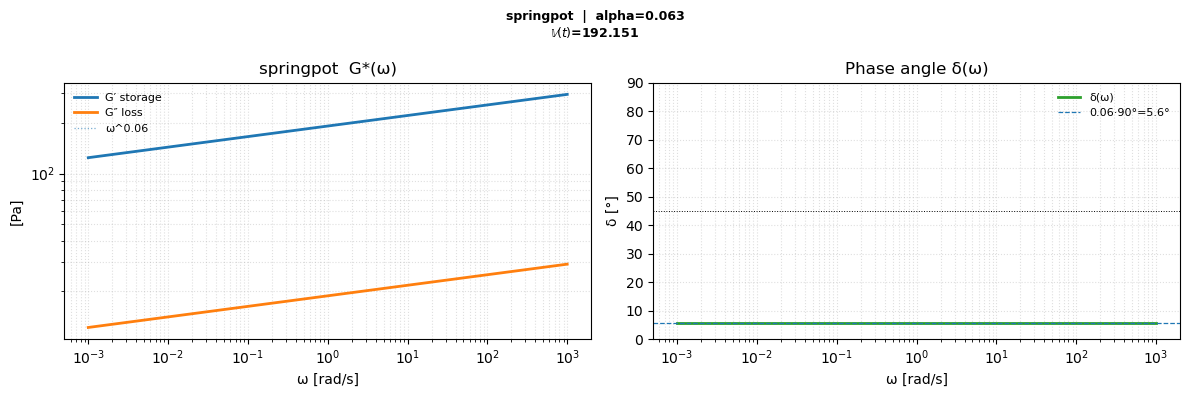

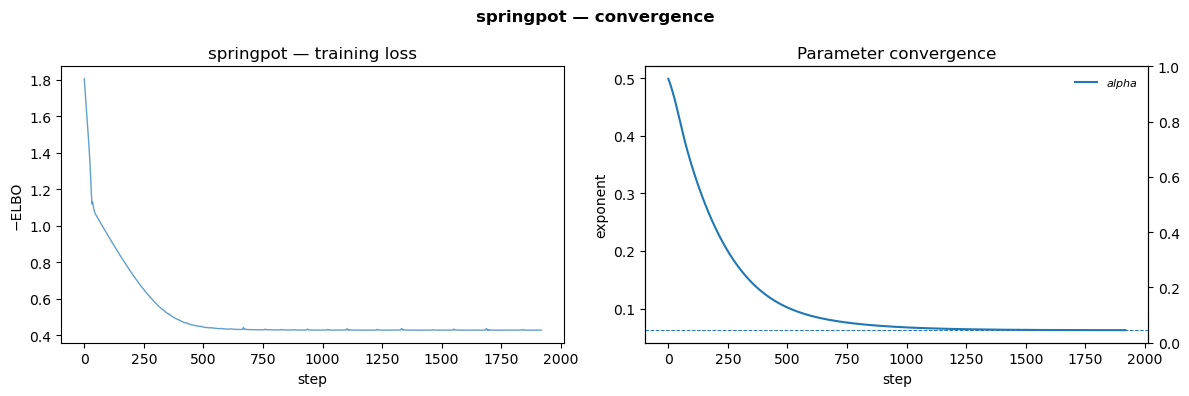

In [19]:
from rheogp import SPGP
from rheogp.utils import compare_models
import pandas as pd
import numpy as np
import time
from pathlib import Path

file_path = Path.cwd().parent / "demos" / "data" / "cnf_chirp.xlsx"
df = pd.read_excel(file_path)

t      = df.iloc[:, 0].values.astype(np.float32)
strain = df.iloc[:, 1].values.astype(np.float32)
stress = df.iloc[:, 2].values.astype(np.float32)

model = SPGP(model="springpot",
             kernel="linear",          # NEW default: two-phase RBF→linear
                                           #   (keep kernel="rbf" for identical-to-before behavior)
             convolution="steady",         # NEW: or "steady" if your chirp is windowed
             quadrature="exact",           # NEW default (use "left" to reproduce v0.1 numbers)
             inducing_points=300, learning_rate=0.005, learning_rate_physics=0.005,
             omega_min=0.001, omega_max=1000, n_epochs=20000)

t0 = time.perf_counter()
model.fit(t, strain, stress)
print(f"Training time: {time.perf_counter()-t0:.1f} s")

print(model.summary())                     # now includes AIC/AICc/BIC + parameter breakdown

sigma_pred, sigma_std = model.predict(strain, return_std=True)

model.plot_fit()
model.plot_prefactors()
model.plot_Gstar()
model.plot_convergence()

# NEW: everything as plain numpy, for your own paper figures
res = model.results()
res.t, res.prediction, res.prediction_std   # fit ± σ
res.features, res.feature_names             # physical features x_i(t)
res.sensitivities["V"]["mean"]             # time-resolved prefactor + CI bands
res.omega, res.Gp, res.Gdp                  # model G', G''
res.metrics["aic"], res.metrics["bic"]      # information criteria
res.save("cnf_scottblair_fit")            # → .npz + .json, reload with FitResult.load()

  [Springpot] step     0 | -ELBO 1.8033 | alpha=0.499 | wait 0
  [Springpot] step   200 | -ELBO 0.7366 | alpha=0.238 | wait 0
  [Springpot] step   400 | -ELBO 0.4786 | alpha=0.127 | wait 0
  [Springpot] step   600 | -ELBO 0.4320 | alpha=0.088 | wait 0
  [Springpot] step   800 | -ELBO 0.4276 | alpha=0.074 | wait 1
  [Springpot] step  1000 | -ELBO 0.4267 | alpha=0.068 | wait 25
  [Springpot] step  1200 | -ELBO 0.4276 | alpha=0.066 | wait 49
  [Springpot] step  1400 | -ELBO 0.4265 | alpha=0.065 | wait 67
  [Springpot] step  1600 | -ELBO 0.4265 | alpha=0.064 | wait 267
  [Springpot] step  1800 | -ELBO 0.4272 | alpha=0.064 | wait 467
  [Springpot] early stopping at step 1833

  [Springpot] RMSE=0.7447  R²=0.8638  AIC=1203.6  BIC=1235.1  (k=6: shape 1 + prefactors 1 + GP 4)
  params: {'alpha': 0.0639483779668808}
  V: 191.16  95%CI [189.455, 192.565]

Model                           AIC        BIC    k    RMSE [Pa]       R²  Params
------------------------------------------------------------

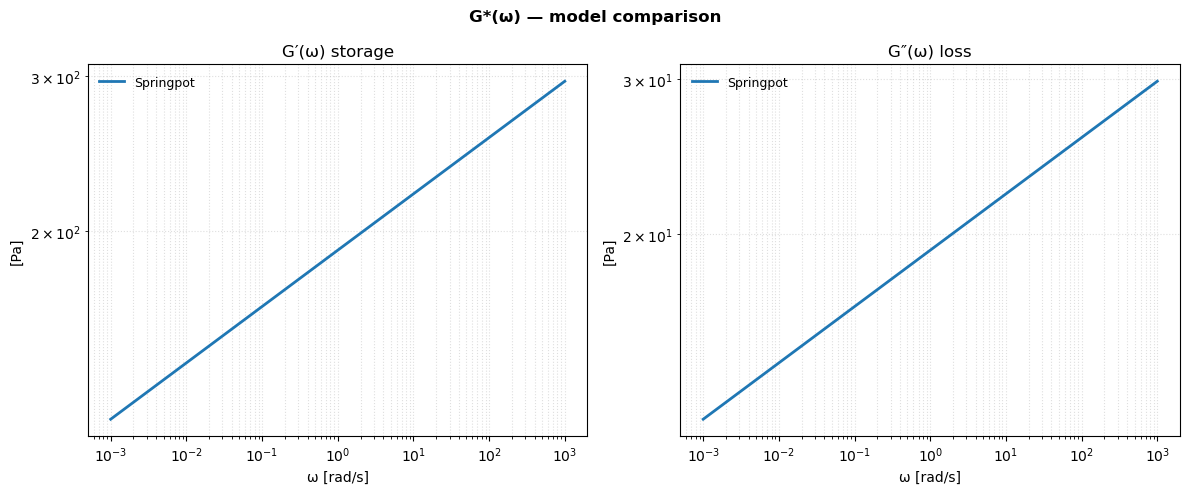

In [27]:
# compare models — now ranks by AIC or BIC, your choice
models = {}
for name in ["Springpot"]:
    models[name] = SPGP(model=name, kernel="linear",          # NEW default: two-phase RBF→linear
                                           #   (keep kernel="rbf" for identical-to-before behavior)
             convolution="causal",         # NEW: or "steady" if your chirp is windowed
             quadrature="exact",           # NEW default (use "left" to reproduce v0.1 numbers)
             inducing_points=300, learning_rate=0.005, learning_rate_physics=0.005,
             omega_min=0.001, omega_max=1000, n_epochs=20000).fit(t, strain, stress)

best = compare_models(models, criterion="bic")   # or criterion="aic"

In [28]:
"""
Residual autocorrelation and information criteria at the effective sample size
=============================================================================
Works directly on a dict of FITTED SPGP objects, as produced by

    models = {}
    for name in ["Maxwell", "FMG", "FML", "FMM", "Springpot"]:
        models[name] = SPGP(...).fit(t, strain, stress)

Reports, for every candidate and both at full N and at the effective
sample size N_eff, the two terms of each criterion separately:

    AIC = 2U + 2k                 BIC = 2U + k ln N
          ^--- fit    ^--- penalty

so that it is visible which term the correlation correction acts on.

USAGE
-----
    import residual_neff as rn
    rows = rn.analyze_models(models, stress, label="wormlike micelles")
    rn.plot_residuals(rows, t)
"""

import numpy as np
import matplotlib.pyplot as plt


# --------------------------------------------------------- autocorrelation
def acf(x, nlags=None):
    """Normalized autocorrelation of a 1-D sequence, lags 0..nlags."""
    x = np.asarray(x, float)
    x = x - x.mean()
    n = x.size
    if nlags is None:
        nlags = min(n - 1, 5000)
    nfft = 1 << int(np.ceil(np.log2(2 * n)))          # zero-pad: no circular wrap
    f = np.fft.rfft(x, nfft)
    r = np.fft.irfft(f * np.conj(f), nfft)[:nlags + 1].real
    return r / r[0]


def tau_int(rho):
    """
    Integrated autocorrelation time by Geyer's initial-positive-sequence rule:
    accumulate consecutive lag PAIRS while their sum stays positive.

    The pairwise truncation is essential for oscillatory residuals, whose
    raw ACF rings indefinitely; a naive sum would diverge or go negative.
    """
    s, k = 0.0, 1
    while k + 1 < rho.size:
        pair = rho[k] + rho[k + 1]
        if pair <= 0:
            break
        s += pair
        k += 2
    return max(1.0 + 2.0 * s, 1.0), k


# ------------------------------------------------------------- main routine
def analyze_models(models, stress, label="", nlags=5000):
    """
    models : dict {name: fitted SPGP}
    stress : the measured stress array used for training
    """
    stress = np.asarray(stress, float)
    rows = []

    for name, m in models.items():
        resid = stress - np.asarray(m.pred_, float)
        N     = resid.size
        rho   = acf(resid, min(nlags, N - 1))
        tau, kcut = tau_int(rho)
        N_eff = N / tau

        U = m.metrics_["nll"]                       # total negative ELBO
        k = m.metrics_["n_params"]["k_total"]

        # --- full N -------------------------------------------------------
        fit_N      = 2.0 * U
        pen_aic_N  = 2.0 * k
        pen_bic_N  = k * np.log(N)

        # --- effective N --------------------------------------------------
        # U = N*u with u the per-point bound; rescale to U_eff = N_eff*u
        U_eff       = U * (N_eff / N)
        fit_eff     = 2.0 * U_eff
        pen_aic_eff = 2.0 * k                        # AIC penalty is N-free
        pen_bic_eff = k * np.log(N_eff)

        rows.append(dict(
            model=name, N=N, tau=tau, N_eff=N_eff, kcut=kcut, k=k,
            rmse=float(np.sqrt((resid ** 2).mean())),
            fit_N=fit_N, pen_aic_N=pen_aic_N, pen_bic_N=pen_bic_N,
            aic_N=fit_N + pen_aic_N, bic_N=fit_N + pen_bic_N,
            fit_eff=fit_eff, pen_aic_eff=pen_aic_eff, pen_bic_eff=pen_bic_eff,
            aic_eff=fit_eff + pen_aic_eff, bic_eff=fit_eff + pen_bic_eff,
            resid=resid, rho=rho))

    # deltas relative to the best candidate under each criterion
    for key, dkey in (("aic_N", "daic_N"), ("bic_N", "dbic_N"),
                      ("aic_eff", "daic_eff"), ("bic_eff", "dbic_eff")):
        best = min(r[key] for r in rows)
        for r in rows:
            r[dkey] = r[key] - best

    rows.sort(key=lambda r: r["dbic_N"])
    _print_table(rows, label)
    return rows


def _print_table(rows, label):
    print(f"\n=== {label} : autocorrelation and effective sample size ===")
    print(f"{'model':10s} {'N':>7s} {'tau_int':>8s} {'N_eff':>9s} {'k':>3s} "
          f"{'RMSE':>10s}")
    for r in rows:
        print(f"{r['model']:10s} {r['N']:7d} {r['tau']:8.1f} {r['N_eff']:9.1f} "
              f"{r['k']:3d} {r['rmse']:10.4g}")

    print(f"\n--- criterion terms at FULL N ---")
    print(f"{'model':10s} {'2U':>12s} {'2k':>8s} {'k lnN':>9s} "
          f"{'AIC':>12s} {'BIC':>12s} {'dAIC':>9s} {'dBIC':>9s}")
    for r in rows:
        print(f"{r['model']:10s} {r['fit_N']:12.1f} {r['pen_aic_N']:8.1f} "
              f"{r['pen_bic_N']:9.1f} {r['aic_N']:12.1f} {r['bic_N']:12.1f} "
              f"{r['daic_N']:9.1f} {r['dbic_N']:9.1f}")

    print(f"\n--- criterion terms at EFFECTIVE N ---")
    print(f"{'model':10s} {'2U_eff':>12s} {'2k':>8s} {'k lnNeff':>9s} "
          f"{'AIC_eff':>12s} {'BIC_eff':>12s} {'dAIC_eff':>9s} {'dBIC_eff':>9s}")
    for r in rows:
        print(f"{r['model']:10s} {r['fit_eff']:12.1f} {r['pen_aic_eff']:8.1f} "
              f"{r['pen_bic_eff']:9.1f} {r['aic_eff']:12.1f} "
              f"{r['bic_eff']:12.1f} {r['daic_eff']:9.1f} {r['dbic_eff']:9.1f}")


# ------------------------------------------------------------------ figure
def plot_residuals(rows, t, which=None):
    """Residual trace and ACF for one model (default: best by BIC at full N)."""
    r = rows[0] if which is None else next(x for x in rows if x["model"] == which)
    t = np.asarray(t, float)

    fig, ax = plt.subplots(1, 2, figsize=(6.2, 2.4))
    ax[0].plot(t, r["resid"], "o", ms=1, alpha=0.5, color="tab:orange",
               rasterized=True)
    ax[0].axhline(0, color="k", lw=0.8)
    ax[0].set_xlabel("$t$ [s]")
    ax[0].set_ylabel(r"$\sigma-\bar{\sigma}$ [Pa]")

    lags = np.arange(r["rho"].size)
    ax[1].plot(lags, r["rho"], "-", color="tab:blue", lw=1.0)
    ax[1].axhline(0, color="k", lw=0.8)
    ax[1].axvline(r["kcut"], color="k", lw=0.6, ls="--",
                  label=f"truncation lag {r['kcut']}")
    ax[1].set_xlabel("lag [samples]")
    ax[1].set_ylabel(r"$\rho_k$")
    ax[1].set_xlim(0, min(4 * r["kcut"] + 20, r["rho"].size))
    ax[1].legend(frameon=False, fontsize=6)
    for a in ax:
        a.grid(False)
    fig.suptitle(f"{r['model']}:  " r"$\tau_{\rm int}=$" f"{r['tau']:.0f},  "
                 r"$N_{\rm eff}=$" f"{r['N_eff']:.0f}", fontsize=8)
    fig.tight_layout()
    plt.show()
    return fig


=== wormlike micelles : autocorrelation and effective sample size ===
model            N  tau_int     N_eff   k       RMSE
Springpot     1397      1.0    1397.0   6     0.7447

--- criterion terms at FULL N ---
model                2U       2k     k lnN          AIC          BIC      dAIC      dBIC
Springpot        1191.6     12.0      43.5       1203.6       1235.1       0.0       0.0

--- criterion terms at EFFECTIVE N ---
model            2U_eff       2k  k lnNeff      AIC_eff      BIC_eff  dAIC_eff  dBIC_eff
Springpot        1191.6     12.0      43.5       1203.6       1235.1       0.0       0.0


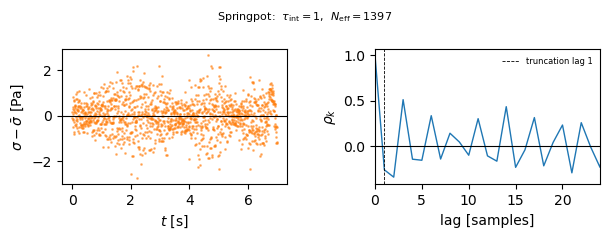

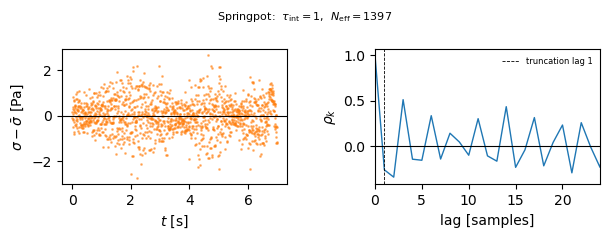

In [29]:
rows = analyze_models(models, stress, label="wormlike micelles")
plot_residuals(rows, t)

In [30]:
n_quiet  = int(1.0 / (t[1] - t[0]))
rho_q    = acf(stress[:n_quiet], nlags=150)
tau_q, _ = tau_int(rho_q)
print(f"instrument noise: tau_int = {tau_q:.2f}")

instrument noise: tau_int = 40.92


In [31]:
r = next(x for x in rows if x["model"] == "Springpot")["resid"]
rho = acf(r, nlags=25)
print(np.round(rho[:12], 3))
print("white-noise 2-sigma band: ±%.3f" % (2/np.sqrt(r.size)))

[ 1.    -0.261 -0.341  0.511 -0.144 -0.155  0.335 -0.142  0.142  0.045
 -0.1    0.302]
white-noise 2-sigma band: ±0.054


In [32]:
import numpy as np

gp, lik = model.gp_model_, model.likelihood_
sy = float(model.scaler_y_.scale_[0])          # Pa per standardized unit

noise_sd = np.sqrt(lik.noise.item()) * sy      # observation noise σ [Pa]
s_f      = np.sqrt(gp.covar_module.outputscale.item()) * sy   # output scale [Pa]

print(f"noise sd = {noise_sd:.3f} Pa")
print(f"s_f      = {s_f:.3f} Pa")
print(f"SNR      = {s_f/noise_sd:.2f}")

sig2, n2 = s_f**2, noise_sd**2
print(f"variance: signal {100*sig2/(sig2+n2):.1f}%  noise {100*n2/(sig2+n2):.1f}%")

# independent cross-check from the residuals
resid = stress - model.pred_
print(f"empirical residual sd = {resid.std():.3f} Pa   (vs GP noise {noise_sd:.3f})")
print(f"R² = {model.metrics_['r2']:.4f}  →  unexplained variance = {1-model.metrics_['r2']:.3f}")

noise sd = 0.747 Pa
s_f      = 1.604 Pa
SNR      = 2.15
variance: signal 82.2%  noise 17.8%
empirical residual sd = 0.746 Pa   (vs GP noise 0.747)
R² = 0.8632  →  unexplained variance = 0.137


In [33]:
import torch, gpytorch

gp, lik = model.gp_model_, model.likelihood_
phys = gp.phys

dev = phys.raw_alpha.device      # whatever device the model is on (cuda:0)

y = torch.as_tensor(
        model.scaler_y_.transform(stress.reshape(-1, 1)).ravel(),
        dtype=torch.float32, device=dev)          # <-- key change

mll = gpytorch.mlls.VariationalELBO(lik, gp, num_data=y.numel())

gp.eval(); lik.eval()
phys._gamma_scale_frozen = phys._feature_stds_frozen = True
raw = phys.raw_alpha
raw.requires_grad_(True)

with gpytorch.settings.cholesky_jitter(1e-6):
    x     = gp.compute_x()
    loss  = -mll(gp(x), y) * y.numel()
    grad, = torch.autograd.grad(loss, raw, create_graph=True)
    hess, = torch.autograd.grad(grad, raw)

phys._gamma_scale_frozen = phys._feature_stds_frozen = False

sd_raw   = float(hess.abs().rsqrt())
alpha    = phys.alpha.item()
sd_alpha = alpha * (1 - alpha) * sd_raw
print(f"alpha = {alpha:.4f} ± {sd_alpha:.4f}")

alpha = 0.0625 ± 0.0064


In [28]:
import numpy as np

# from the Laplace step above:
#   alpha, sd_alpha
# from the linear-kernel fit:
info = model.prefactors_["V"]
V    = info["scalar_mean"]
sd_V = (info["scalar_upper"] - info["scalar_lower"]) / 3.92

omega = np.logspace(-1, 2, 200)
c, s  = np.cos(np.pi*alpha/2), np.sin(np.pi*alpha/2)
Gp    = V * omega**alpha * c
Gdp   = V * omega**alpha * s

# partials
dGp_dV,  dGdp_dV  = Gp / V,               Gdp / V
dGp_da   = Gp  * (np.log(omega) - (np.pi/2)*np.tan(np.pi*alpha/2))
dGdp_da  = Gdp * (np.log(omega) + (np.pi/2)/np.tan(np.pi*alpha/2))

# first-order variances (cov(V, alpha) = 0 in the two-stage scheme)
var_Gp  = (dGp_dV  * sd_V)**2 + (dGp_da  * sd_alpha)**2
var_Gdp = (dGdp_dV * sd_V)**2 + (dGdp_da * sd_alpha)**2
sd_Gp, sd_Gdp = np.sqrt(var_Gp), np.sqrt(var_Gdp)

# 2-sigma bands: Gp ± 2*sd_Gp, Gdp ± 2*sd_Gdp


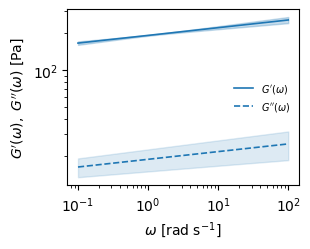

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# ---- inputs from the fit + Laplace step ----
info = model.prefactors_["V"]
V    = info["scalar_mean"]
sd_V = (info["scalar_upper"] - info["scalar_lower"]) / 3.92
# alpha, sd_alpha already computed by your Laplace snippet

# ---- G*(omega) and its delta-method bands ----
omega = np.logspace(-1, 2, 300)          # match your excited band
c, s  = np.cos(np.pi*alpha/2), np.sin(np.pi*alpha/2)
Gp    = V * omega**alpha * c
Gdp   = V * omega**alpha * s

dGp_da  = Gp  * (np.log(omega) - (np.pi/2)*np.tan(np.pi*alpha/2))
dGdp_da = Gdp * (np.log(omega) + (np.pi/2)/np.tan(np.pi*alpha/2))
sd_Gp   = np.sqrt((Gp /V*sd_V)**2 + (dGp_da *sd_alpha)**2)
sd_Gdp  = np.sqrt((Gdp/V*sd_V)**2 + (dGdp_da*sd_alpha)**2)

# ---- plot ----
fig, ax = plt.subplots(figsize=(3.2, 2.6))

ax.plot(omega, Gp, "-", color="tab:blue", lw=1.2, label=r"$G'(\omega)$")
ax.fill_between(omega, Gp-2*sd_Gp, Gp+2*sd_Gp, color="tab:blue", alpha=0.25)

ax.plot(omega, Gdp, "--", color="tab:blue", lw=1.2, label=r"$G''(\omega)$")
ax.fill_between(omega, Gdp-2*sd_Gdp, Gdp+2*sd_Gdp, color="tab:blue", alpha=0.15)

# optional: DFT estimates from res if you have them
# ax.plot(res.fft_omega, res.fft_Gp, "o", color="k", ms=2)
# ax.plot(res.fft_omega, res.fft_Gdp, "o", mfc="none", color="k", ms=2)

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"$\omega$ [rad s$^{-1}$]")
ax.set_ylabel(r"$G'(\omega),\ G''(\omega)$ [Pa]")
ax.legend(frameon=False, fontsize=7)
fig.tight_layout()
plt.show()

talpha  = 0.0625 s
V     = 192.1508 Pa
95% CI = [190.5407, 193.4776] Pa
sy = 2.0178 Pa  |  sm = 0.6311 Pa
Pre-step baseline: 0.470380 Pa
After offset removal — range: [-0.0934, 0.2775] Pa


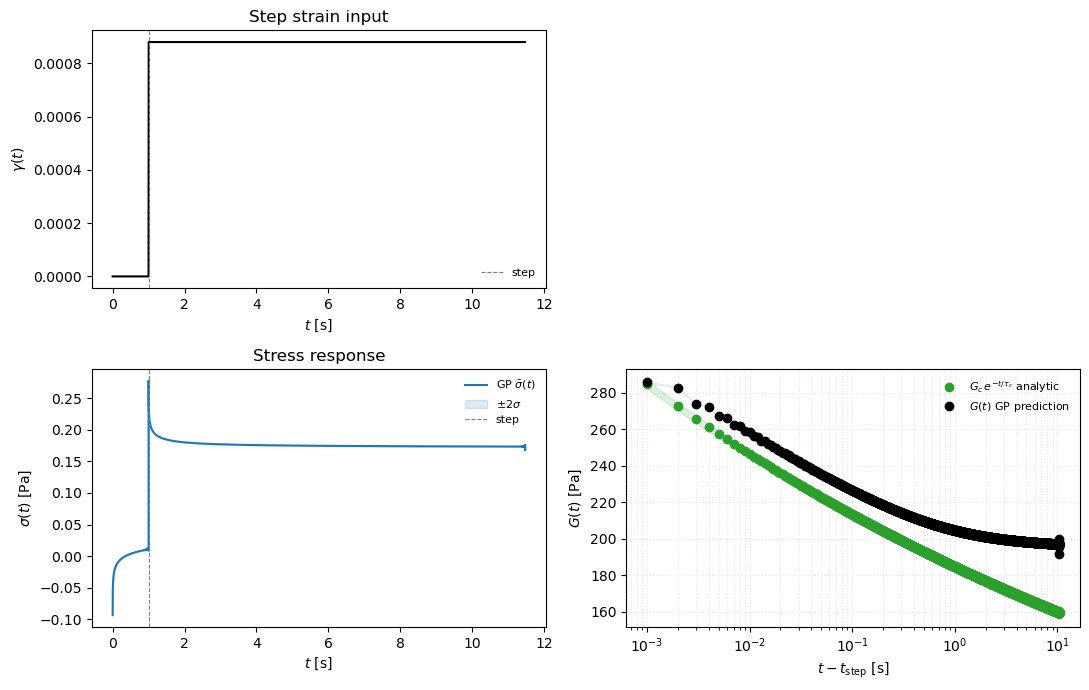

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# ── parameters from the Maxwell model ───────────────────────
alpha  = model.gp_model_.phys.named_phys_params()["alpha"]
V     = model.prefactors_["V"]["scalar_mean"]
V_lo  = model.prefactors_["V"]["scalar_lower"]
V_hi  = model.prefactors_["V"]["scalar_upper"]

print(f"talpha  = {alpha:.4f} s")
print(f"V     = {V:.4f} Pa")
print(f"95% CI = [{V_lo:.4f}, {V_hi:.4f}] Pa")


# ── scalers ──────────────────────────────────────────────────
sy = float(model.scaler_y_.scale_[0])   # σ_y
sm = float(model.scaler_y_.mean_[0])    # μ_y  ← the offset
print(f"sy = {sy:.4f} Pa  |  sm = {sm:.4f} Pa")

# ── step strain with 1s wait before step ────────────────────
dt_step     = 1 / 1000
t_end       = 1 + (2 * np.pi / (1* 0.6))
t_step      = np.arange(0.0, t_end, dt_step)
gamma_0     = 8.8e-4
t_step_on   = 1
step_strain = np.zeros_like(t_step)
step_strain[t_step >= t_step_on] = gamma_0
#step_strain += np.random.randn(len(t_step)) * gamma_0 * 1e-8  # tiny noise

# ── predict ──────────────────────────────────────────────────
sigma_step, sigma_step_std = model.predict(
    step_strain, time=t_step, return_std=True
)

# remove sm offset — unphysical for step strain
# (sm is the training stress mean added back by StandardScaler)
# ── zero baseline from pre-step region ──────────────────────
mask_pre    = t_step < t_step_on
baseline    = sigma_step[mask_pre].mean()
baseline_std    = sigma_step_std[mask_pre].mean()

print(f"Pre-step baseline: {baseline:.6f} Pa")

sigma_step  = sigma_step - baseline
sigma_step_std = sigma_step_std - baseline_std
print(f"After offset removal — range: [{sigma_step.min():.4f}, {sigma_step.max():.4f}] Pa")

from scipy.special import gamma as sc_gamma
# ── analytic G(t) for Maxwell ────────────────────────────────
mask_relax    = t_step > (t_step_on + dt_step)
t_relax       = t_step[mask_relax] - t_step_on
G_analytic    = V * t_relax**(-alpha) / sc_gamma(1 - alpha)
G_analytic_lo = V_lo * t_relax**(-alpha) / sc_gamma(1 - alpha)
G_analytic_hi = V_hi * t_relax**(-alpha) / sc_gamma(1 - alpha)

# ── figure: 2×2 layout ───────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(11, 7))

# top-left: strain
ax = axes[0, 0]
ax.plot(t_step, step_strain, color="black", lw=1.5)
ax.axvline(t_step_on, color="gray", lw=0.8, ls="--", label="step")
ax.set_xlabel("$t$ [s]")
ax.set_ylabel(r"$\gamma(t)$")
ax.set_title("Step strain input")
ax.legend(fontsize=8, frameon=False)
ax.grid(False)

# top-right: off
axes[0, 1].axis("off")

# bottom-left: stress
ax = axes[1, 0]
ax.plot(t_step, sigma_step, color="tab:blue", lw=1.5,
        label=r"GP $\bar{\sigma}(t)$")
ax.fill_between(t_step,
                sigma_step - 1.96 * (sigma_step_std),
                sigma_step + 1.96 * (sigma_step_std),
                color="tab:blue", alpha=0.15, label=r"$\pm 2\sigma$")
ax.axvline(t_step_on, color="gray", lw=0.8, ls="--", label="step")
ax.set_xlabel("$t$ [s]")
ax.set_ylabel(r"$\sigma(t)$ [Pa]")
ax.set_title("Stress response")
ax.legend(fontsize=8, frameon=False)
ax.grid(False)

# bottom-right: relaxation modulus
ax = axes[1, 1]
mask_gp = t_step > (t_step_on + dt_step)
t_gp    = t_step[mask_gp] - t_step_on
G_gp    = sigma_step[mask_gp] / gamma_0
G_gp_lo = (sigma_step[mask_gp] - 1.96 * (sigma_step_std[mask_gp] )) / gamma_0
G_gp_hi = (sigma_step[mask_gp] + 1.96 * (sigma_step_std[mask_gp] )) / gamma_0

ax.fill_between(t_relax, G_analytic_lo, G_analytic_hi,
                color="tab:green", alpha=0.15)
ax.plot(t_relax, G_analytic, "o", color="tab:green", lw=2.0,
        label=r"$G_c\,e^{-t/\tau_c}$ analytic")
ax.fill_between(t_gp, G_gp_lo, G_gp_hi,
                color="tab:blue", alpha=0.15)
ax.plot(t_gp, G_gp, "o",color="k",
        label=r"$G(t)$ GP prediction")
ax.set_xscale("log")
#ax.set_xlim(2*np.pi/100, 2*np.pi/0.03)
ax.set_yscale("linear")
#ax.set_ylim(0.2e8, 0.5e8)
ax.set_xlabel(r"$t - t_{\mathrm{step}}$ [s]")
ax.set_ylabel("$G(t)$ [Pa]")
ax.legend(fontsize=8, frameon=False)
ax.grid(True, which="both", ls=":", alpha=0.3)


plt.tight_layout()
plt.show()